# WiniCari -- 08 Exploration : Enrichissement des Coordonnées d'Arrêts

Deux nouvelles bases MongoDB sont disponibles pour combler le déficit de coordonnées d'arrêts
qui limite aujourd'hui la fondation (seules 143 lignes / 3 sociétés ont des arrêts géocodés) :

| Base | Contenu |
|------|---------|
| `Historique_Tickets` | 5,4 M tickets individuels (2019-2026), 11 sociétés. Chaque ticket porte les noms de gare origine/destination, un **code d'ordre** (`origine`/`Distination`), la ligne, le bus, et un horodatage à la minute. |
| `OpenData` | Dictionnaire de stations `nom -> (lat, lng)` réparti sur 4 collections (`Station`, `Station2`, `Station_new`, `Station_sts`), plus géographie administrative (`Delegation`, `GOV`) et historique météo par station. |

Ce notebook explore les deux bases, mesure la couverture **actuelle** de la fondation (avant
enrichissement), puis valide la méthode de combinaison (ordre des tickets + coordonnées
OpenData) sur des lignes connues.


---
## 0. Configuration

In [1]:
from pathlib import Path
import sys, os
sys.path.insert(0, str(Path.cwd().parent))
os.environ.setdefault("PYTHONIOENCODING", "utf-8")

import warnings
warnings.filterwarnings("ignore")

import unicodedata, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient
from IPython.display import display

from src.data.foundation import build_usable_lines, Config, real_anchor_stops

client = MongoClient()
wi = client["winicari"]
od = client["OpenData"]
tk = client["Historique_Tickets"]
gps = client["Historique_pos"]

def norm(s):
    """Clé de comparaison : NFKD, majuscule, alphanumérique uniquement."""
    if not s:
        return ""
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return re.sub(r"[^A-Z0-9]", "", s.upper())

def haversine(a, b, x, y):
    R = 6371000; p = np.pi / 180
    d = (np.sin((x - a) * p / 2) ** 2 + np.cos(a * p) * np.cos(x * p) * np.sin((y - b) * p / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(d))


---
## 1. Inventaire des nouvelles bases

In [2]:
print("=== Toutes les bases MongoDB ===")
for db in client.list_database_names():
    if db in ["admin", "config", "local"]:
        continue
    cols = client[db].list_collection_names()
    print(f"  {db}: {len(cols)} collections")


=== Toutes les bases MongoDB ===
  Historique_Tickets: 8 collections
  Historique_pos: 1603 collections
  OpenData: 8 collections
  winicari: 55 collections


In [3]:
print("=== Historique_Tickets ===")
for col in tk.list_collection_names():
    print(f"  {col}: {tk[col].count_documents({}):,} docs")

print("\n=== OpenData ===")
for col in od.list_collection_names():
    print(f"  {col}: {od[col].count_documents({}):,} docs")


=== Historique_Tickets ===


  Ticket2020: 216,639 docs


  Ticket2025: 926,743 docs


  Ticket2024: 1,080,200 docs


  Ticket2022: 1,270,905 docs


  Ticket2026: 383,239 docs


  Ticket2023: 491,108 docs


  Ticket2019: 241,725 docs


  Ticket2021: 876,158 docs

=== OpenData ===
  Delegation: 264 docs
  historiqueJourMeteo: 1,252 docs
  Station2: 2,525 docs
  Station_sts: 1,113 docs
  USER: 6 docs
  GOV: 24 docs
  Station: 2,898 docs
  Station_new: 1,212 docs


### 1.1 Schémas -- un document type par collection

In [4]:
def show(dbname, col, n=2):
    d = client[dbname][col]
    doc = d.find_one()
    if not doc:
        print(f"{dbname}.{col}: VIDE"); return
    print(f"--- {dbname}.{col} ---")
    print("champs:", list(doc.keys()))
    for x in d.find().limit(n):
        x.pop("_id", None); x.pop("_class", None)
        print({k: str(v)[:50] for k, v in x.items()})
    print()

show("Historique_Tickets", "Ticket2025")
show("OpenData", "Station")
show("OpenData", "Station2")
show("OpenData", "Station_new")
show("OpenData", "Station_sts")
show("OpenData", "Delegation")
show("OpenData", "GOV")
show("OpenData", "historiqueJourMeteo")


--- Historique_Tickets.Ticket2025 ---
champs: ['_id', 'IDTicket', 'CodeBus', 'CodeCh', 'CodeConv', 'Codeligne', 'NomFR1', 'NomAR1', 'NomFR2', 'NomAR2', 'Prix', 'CodeRoute', 'origine', 'Distination', 'Num', 'requisition', 'voyage', 'faveur', 'Nserie', 'bagage', 'Paiement', 'Recharge', 'reduction', 'typeReq', 'NumeReq', 'TypeReplay', 'Societe', 'date_debut_service', 'heure_debut_ticket', 'date_fin_service', 'heure_fin_ticket', 'stats', 'stat_detail', 'date', 'date_service', 'date_ticket', 'jour_service', 'Heure_ticket']
{'IDTicket': '116654', 'CodeBus': '6030', 'CodeCh': '5930', 'CodeConv': '5915', 'Codeligne': '00', 'NomFR1': 'KASSERINE', 'NomAR1': 'القصرين', 'NomFR2': 'SOUSSE', 'NomAR2': 'سوسة', 'Prix': '10.0', 'CodeRoute': '212', 'origine': '01', 'Distination': '22', 'Num': '23', 'requisition': 'N', 'voyage': '2', 'faveur': 'N', 'Nserie': 'BS-18-0008', 'bagage': 'O', 'Paiement': 'N', 'Recharge': 'N', 'reduction': '0', 'typeReq': '[]', 'NumeReq': '[]', 'TypeReplay': 'N', 'Societe': 'S.

### 1.2 Volume de tickets par année et société

Les tickets couvrent **11 sociétés**, contre seulement 3 avec des données GPS exploitables
aujourd'hui (S.R.T.K, S.T.S, TCV) -- c'est la première preuve que cet enrichissement dépasse
largement la portée actuelle.

In [5]:
rows = []
for yr in ["2019","2020","2021","2022","2023","2024","2025","2026"]:
    col = f"Ticket{yr}"
    n = tk[col].count_documents({})
    socs = tk[col].distinct("Societe")
    rows.append({"année": yr, "tickets": n, "sociétés": len(socs), "liste": ", ".join(sorted(socs))})
df_years = pd.DataFrame(rows)
display(df_years)
print(f"\nTotal tickets: {df_years['tickets'].sum():,}")


,année,tickets,sociétés,liste
0,2019,241725,5,"S.R.T.BIZERTE, S.R.T.K, S.R.T.K0, S.R.T.M, Win..."
1,2020,216639,6,"S.R.T.BIZERTE, S.R.T.K, S.R.T.K0, S.R.T.M, SOR..."
2,2021,876158,5,"S.R.T.BIZERTE, S.R.T.K, S.R.T.K0, S.T.C.I, S.T.S"
3,2022,1270905,7,"EPE-TVE, S.R.T.BIZERTE, S.R.T.K, S.R.T.K0, S.T..."
4,2023,491108,6,"EPE-TVE, S.R.T.BIZERTE, S.R.T.K, S.R.T.K0, S.T..."
5,2024,1080200,7,"S.R.T.K, S.R.T.K0, S.T.S, SRT.ELGOUAFEL, TCV, ..."
6,2025,926743,6,"S.R.T.K, S.R.T.K0, S.R.T.SELIANA, S.T.S, SRT.E..."
7,2026,383239,7,"S.R.T.K, S.R.T.K0, S.R.T.SELIANA, S.T.S, SRT.E..."



Total tickets: 5,486,717


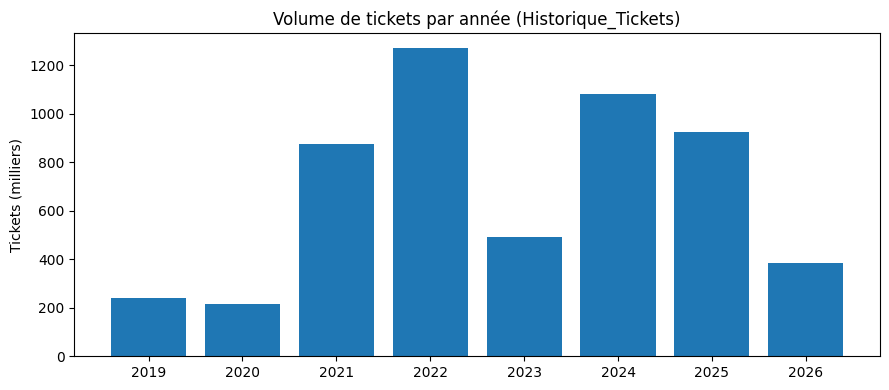

In [6]:
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(df_years["année"], df_years["tickets"]/1000)
ax.set_ylabel("Tickets (milliers)")
ax.set_title("Volume de tickets par année (Historique_Tickets)")
plt.tight_layout(); plt.show()


### 1.3 Les codes `origine` / `Distination` encodent l'ordre des arrêts

Sur la ligne 212 (S.R.T.K), le code `origine` croît de façon monotone avec la position
géographique réelle de l'arrêt -- c'est un **ordre de ligne prêt à l'emploi**, indépendant
des ancres GPS.

In [7]:
pipe = [{"$match": {"CodeRoute": "212", "Societe": "S.R.T.K"}},
        {"$group": {"_id": {"o": "$origine", "n": "$NomFR1"}, "c": {"$sum": 1}}},
        {"$sort": {"_id.o": 1}}]
seen = set()
rows = []
for d in tk["Ticket2025"].aggregate(pipe):
    o, n = d["_id"]["o"], d["_id"]["n"]
    if o not in seen:
        seen.add(o)
        rows.append({"origine": o, "nom": n, "n_tickets": d["c"]})
display(pd.DataFrame(rows))


,origine,nom,n_tickets
0,01,KASSERINE,21294
1,02,BOUZGUEM,140
2,03,EL GARAA,2
3,04,CHRAYA,286
4,05,SBEITLA,2005
5,06,M'GHILLA,167
6,07,BLAKATJELMA,80
7,08,CHASTEL,6
8,09,EL HAJEB,265
9,10,RHIMA,57


---
## 2. Couverture actuelle de la fondation (référence -- avant enrichissement)

In [8]:
print("Construction des lignes utilisables (logique actuelle)...")
usable = build_usable_lines(wi, Config())

all_stop_names_cur = set()
total_stop_rows = 0
per_company = {}
for (code_, soc), sf in usable.items():
    per_company.setdefault(soc, {"lignes": 0, "arrets": 0})
    per_company[soc]["lignes"] += 1
    per_company[soc]["arrets"] += len(sf)
    total_stop_rows += len(sf)
    for nm in sf["name"]:
        all_stop_names_cur.add(norm(nm))

print(f"Lignes utilisables : {len(usable)}")
print(f"Lignes d'arrêts mappées (total) : {total_stop_rows}")
print(f"Noms d'arrêts uniques mappés : {len(all_stop_names_cur)}")
df_baseline = pd.DataFrame(per_company).T.sort_index()
display(df_baseline)


Construction des lignes utilisables (logique actuelle)...


Lignes utilisables : 143
Lignes d'arrêts mappées (total) : 2067
Noms d'arrêts uniques mappés : 287


,lignes,arrets
EPE-TVE,35,458
S.R.T.BIZERTE,14,121
S.R.T.K,36,602
S.R.T.M,2,60
S.T.C.I,2,46
S.T.S,15,207
SORETRAS,9,97
TCV,1,6
TUS,1,5
Winicari,2,24


In [9]:
total_ligne = wi["ligne"].count_documents({})
dropped = 0
droppable_names = set()
for lg in wi["ligne"].find({}):
    anc = real_anchor_stops(lg)
    if len(anc) < 4:
        dropped += 1
        for nm in (lg.get("stationnames") or []):
            if nm:
                droppable_names.add(norm(nm))

print(f"Documents `ligne` au total : {total_ligne}")
print(f"Lignes ABANDONNÉES (< 4 ancres géocodées) : {dropped} ({100*dropped/total_ligne:.0f}%)")
print(f"Noms d'arrêts distincts sur les lignes abandonnées : {len(droppable_names)}")


Documents `ligne` au total : 402
Lignes ABANDONNÉES (< 4 ancres géocodées) : 266 (66%)
Noms d'arrêts distincts sur les lignes abandonnées : 59


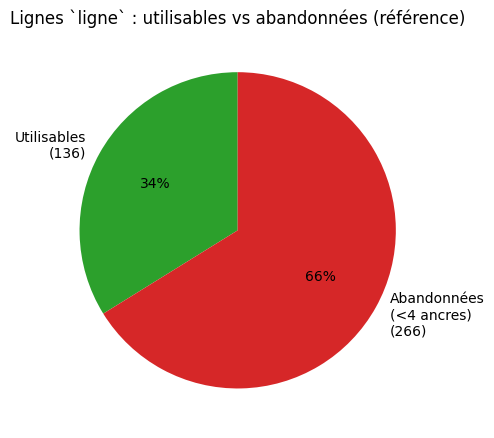

In [10]:
fig, ax = plt.subplots(figsize=(5,5))
sizes = [total_ligne - dropped, dropped]
labels = [f"Utilisables\n({sizes[0]})", f"Abandonnées\n(<4 ancres)\n({sizes[1]})"]
colors = ["#2ca02c", "#d62728"]
ax.pie(sizes, labels=labels, colors=colors, autopct="%1.0f%%", startangle=90)
ax.set_title("Lignes `ligne` : utilisables vs abandonnées (référence)")
plt.tight_layout(); plt.show()


---
## 3. Dictionnaire de coordonnées OpenData

In [11]:
def load_stations(col):
    rows = []
    for d in od[col].find({}, {"nom_fr": 1, "lat": 1, "lng": 1, "_id": 0}):
        try:
            lat, lng = float(d.get("lat")), float(d.get("lng"))
        except (TypeError, ValueError):
            continue
        if abs(lat) > 1 and abs(lng) > 1 and d.get("nom_fr"):
            rows.append((norm(d["nom_fr"]), lat, lng))
    return rows

od_all = {}
summary = []
for col in ["Station", "Station2", "Station_new", "Station_sts"]:
    r = load_stations(col)
    summary.append({"collection": col, "lignes_valides": len(r), "noms_uniques": len(set(x[0] for x in r))})
    for nm, lat, lng in r:
        od_all.setdefault(nm, (lat, lng))

display(pd.DataFrame(summary))
print(f"\nDictionnaire OpenData combiné -- noms de stations uniques : {len(od_all)}")


,collection,lignes_valides,noms_uniques
0,Station,2202,2106
1,Station2,1832,1802
2,Station_new,1212,1191
3,Station_sts,1113,1104



Dictionnaire OpenData combiné -- noms de stations uniques : 3358


### 3.1 Recoupement des noms

Combien des noms d'arrêts des lignes abandonnées peuvent être résolus via OpenData ?
Et combien des noms qui apparaissent dans les tickets ?

In [12]:
new_from_od = droppable_names & set(od_all)
print(f"Noms d'arrêts (lignes abandonnées) résolus par OpenData : {len(new_from_od)} "
      f"({100*len(new_from_od)/max(1,len(droppable_names)):.0f}% des noms abandonnés)")

already = all_stop_names_cur & set(od_all)
print(f"Noms déjà mappés aujourd'hui également présents dans OpenData (recoupement / correction) : {len(already)}")


Noms d'arrêts (lignes abandonnées) résolus par OpenData : 42 (71% des noms abandonnés)
Noms déjà mappés aujourd'hui également présents dans OpenData (recoupement / correction) : 234


In [13]:
sample = list(tk["Ticket2025"].find(
    {}, {"NomFR1": 1, "NomFR2": 1, "date": 1, "_id": 0}).limit(5000))
tk_names = set()
for d in sample:
    for k in ("NomFR1", "NomFR2"):
        if d.get(k):
            tk_names.add(norm(d[k]))

print(f"Noms de stations distincts (échantillon 5k tickets 2025) : {len(tk_names)}")
tk_in_od = tk_names & set(od_all)
print(f"Résolus par OpenData : {len(tk_in_od)} ({100*len(tk_in_od)/max(1,len(tk_names)):.0f}%)")
tk_unmapped = tk_names - set(od_all) - all_stop_names_cur
print(f"Sans coordonnée nulle part (candidats triangulation GPS x ticket) : {len(tk_unmapped)}")


Noms de stations distincts (échantillon 5k tickets 2025) : 140
Résolus par OpenData : 91 (65%)
Sans coordonnée nulle part (candidats triangulation GPS x ticket) : 42


---
## 4. Liaison Tickets <-> GPS (faisabilité de la triangulation)

In [14]:
day = "d20250203"
gps_buses = set(str(b) for b in gps[day].distinct("bus.code") if b is not None)
tk_rows = list(tk["Ticket2025"].find(
    {"jour_service": "2025/02/03"},
    {"CodeBus": 1, "CodeRoute": 1, "NomFR1": 1, "date": 1, "_id": 0}).limit(3000))
tk_buses = set(str(d.get("CodeBus")) for d in tk_rows if d.get("CodeBus"))
inter = tk_buses & gps_buses

print(f"Bus GPS ce jour-là : {len(gps_buses)} | bus billets : {len(tk_buses)} | recoupement : {len(inter)}")

if inter:
    b = sorted(inter)[0]
    tks = [d for d in tk_rows if str(d.get("CodeBus")) == b][:5]
    print(f"\nBillets du bus {b} :")
    for d in tks:
        print(f"  {d.get('date')}  ligne={d.get('CodeRoute')}  origine={d.get('NomFR1')}")
    gp = gps[day].count_documents({"bus.code": int(b) if b.isdigit() else b})
    print(f"Pings GPS pour le bus {b} ce jour-là : {gp:,}")


Bus GPS ce jour-là : 15 | bus billets : 35 | recoupement : 13

Billets du bus 157 :
  2025/02/03 06:50:00  ligne=4  origine=El Manar 2
  2025/02/03 06:53:00  ligne=4  origine=El Manar 2
  2025/02/03 06:53:00  ligne=4  origine=El Manar 2
  2025/02/03 06:53:00  ligne=4  origine=El Manar 2
  2025/02/03 06:55:00  ligne=4  origine=El Manar 2
Pings GPS pour le bus 157 ce jour-là : 9,358


**Conclusion** : les codes bus des tickets recoupent bien ceux du GPS le même jour, avec des
milliers de pings disponibles par bus. La triangulation ticket-heure x ping-GPS est donc
**faisable** pour les ~`len(tk_unmapped)` noms de stations qui n'ont de coordonnée dans aucune des deux sources.


---
## 5. Validation : ordre des tickets + coordonnées OpenData -> route cohérente

In [15]:
def ticket_ordered_stops(line, soc, year="Ticket2025"):
    """Arrêts ordonnés (code -> nom dominant) à partir des tickets, origine + destination."""
    code_name = {}
    pipe = [{"$match": {"CodeRoute": str(line), "Societe": soc}},
            {"$group": {"_id": {"c": "$origine", "n": "$NomFR1"}, "k": {"$sum": 1}}}]
    for d in tk[year].aggregate(pipe):
        c, n = d["_id"]["c"], d["_id"]["n"]
        if c and n:
            code_name.setdefault(c, {}).setdefault(n, 0)
            code_name[c][n] += d["k"]
    pipe2 = [{"$match": {"CodeRoute": str(line), "Societe": soc}},
             {"$group": {"_id": {"c": "$Distination", "n": "$NomFR2"}, "k": {"$sum": 1}}}]
    for d in tk[year].aggregate(pipe2):
        c, n = d["_id"]["c"], d["_id"]["n"]
        if c and n:
            code_name.setdefault(c, {}).setdefault(n, 0)
            code_name[c][n] += d["k"]
    rows = []
    for c, names in code_name.items():
        try:
            cn = int(c)
        except (TypeError, ValueError):
            continue
        rows.append((cn, max(names, key=names.get)))
    rows.sort()
    return rows

results = {}
for line, soc in [("212", "S.R.T.K"), ("217", "S.R.T.K"), ("500", "S.R.T.K")]:
    stops = ticket_ordered_stops(line, soc)
    resolved = [(cn, nm, od_all.get(norm(nm))) for cn, nm in stops]
    ok = [(cn, nm, r) for cn, nm, r in resolved if r]
    results[line] = resolved
    print(f"=== Ligne {line} ({soc}) : {len(stops)} arrêts billets, {len(ok)} résolus via OpenData ===")
    if len(ok) >= 2:
        lats = [r[0] for _, _, r in ok]; lons = [r[1] for _, _, r in ok]
        seg = [haversine(lats[i], lons[i], lats[i+1], lons[i+1]) for i in range(len(ok)-1)]
        print(f"  longueur de route : {sum(seg)/1000:.0f} km")
    for cn, nm, r in resolved:
        tag = "OK " if r else "?? "
        print(f"  {tag}{cn:>3} {nm}")
    print()


=== Ligne 212 (S.R.T.K) : 22 arrêts billets, 22 résolus via OpenData ===
  longueur de route : 245 km
  OK   1 KASSERINE
  OK   2 BOUZGUEM
  OK   3 EL GARAA
  OK   4 CHRAYA
  OK   5 SBEITLA
  OK   6 M'GHILLA
  OK   7 BLAKATJELMA
  OK   8 CHASTEL
  OK   9 EL HAJEB
  OK  10 RHIMA
  OK  11 EL FOUNDEK
  OK  12 EL HOUAREB
  OK  13 BLAKHAFFOUZ
  OK  14 CHEBIKA
  OK  15 EL MADRESSA
  OK  16 EL BATEN
  OK  17 KAIROUAN
  OK  18 EL KHDRAOUI
  OK  19 SIDI ELHENI
  OK  20 GHABGOUB
  OK  21 M'SAKEN
  OK  22 SOUSSE



=== Ligne 217 (S.R.T.K) : 30 arrêts billets, 30 résolus via OpenData ===
  longueur de route : 311 km
  OK   1 KASSERINE
  OK   2 BOUZGUEM
  OK   3 EL GARAA
  OK   4 CHRAYA
  OK   5 SBEITLA
  OK   6 M'GHILLA
  OK   7 BLAKATJELMA
  OK   8 CHASTEL
  OK   9 EL HAJEB
  OK  10 RHIMA
  OK  11 EL FOUNDEK
  OK  12 EL HOUAREB
  OK  13 BLAKHAFFOUZ
  OK  14 CHEBIKA
  OK  15 KAIROUAN
  OK  16 MAKHSOUMA
  OK  17 MAD MANE3
  OK  18 WLAD CHAMEK
  OK  19 WLAD BOUZID
  OK  20 ECHHIMET NORD
  OK  21 ECHHIMET SUD
  OK  22 SIDI ZID
  OK  23 ESSWASSI
  OK  24 EL JEM
  OK  25 ETLALSSA
  OK  26 ESSAADA
  OK  27 SAKIET KHADEM
  OK  28 KSOUR ESSAF
  OK  29 ERREJICHE
  OK  30 MAHDIA



=== Ligne 500 (S.R.T.K) : 18 arrêts billets, 10 résolus via OpenData ===
  longueur de route : 170 km
  OK   1 EL MEJEL
  OK   2 FRIANA
  OK   3 THELEPTE
  OK   4 KASSERINE
  OK   5 SBEITLA
  OK   6 M'GHILLA
  OK   7 BLAKATJELMA
  OK   8 EL HAJEB
  ??   9 FAHS
  OK  10 EL HOUAREB
  OK  11 CHEBIKA
  ??  12 TUNIS
  ??  13 ESBIKHA
  ??  14 BIR NADOUR
  ??  15 FAHS
  ??  16 BIR MCHERGA
  ??  17 JBAL EL OUOST
  ??  18 BAB ALLOUIA



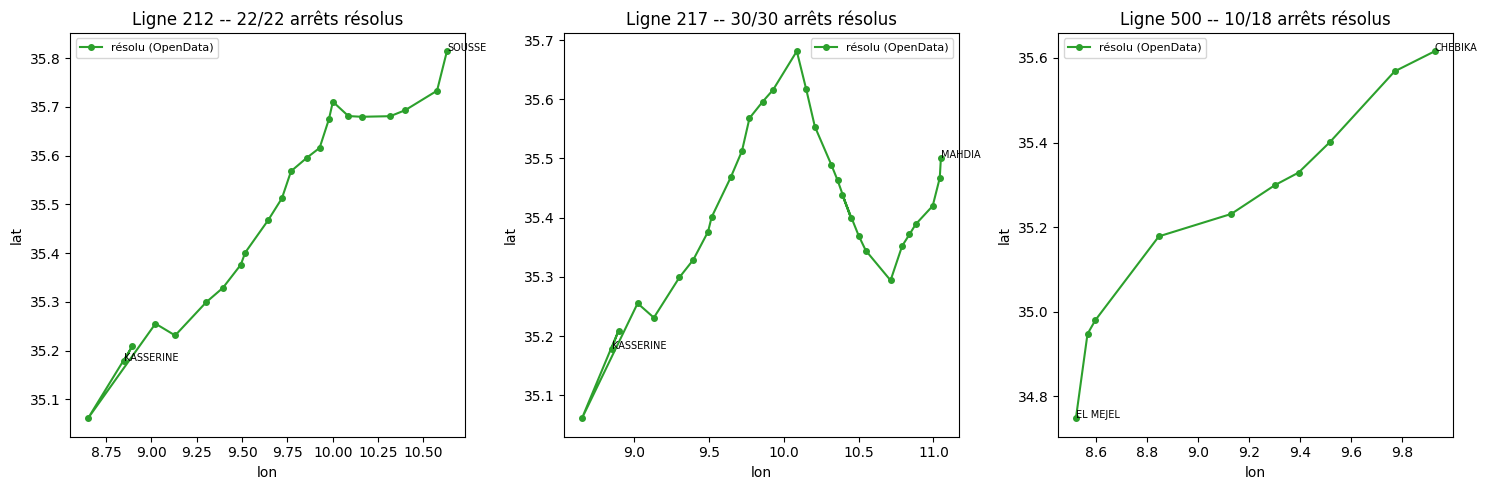

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (line, resolved) in zip(axes, results.items()):
    ok = [(cn, nm, r) for cn, nm, r in resolved if r]
    missing = [(cn, nm) for cn, nm, r in resolved if not r]
    if ok:
        lats = [r[0] for _, _, r in ok]; lons = [r[1] for _, _, r in ok]
        ax.plot(lons, lats, "-o", color="#2ca02c", markersize=4, label="résolu (OpenData)")
        ax.annotate(ok[0][1], (lons[0], lats[0]), fontsize=7)
        ax.annotate(ok[-1][1], (lons[-1], lats[-1]), fontsize=7)
    ax.set_title(f"Ligne {line} -- {len(ok)}/{len(resolved)} arrêts résolus")
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 6. Conclusions de l'exploration

- **Couverture actuelle (référence)** : 143 lignes utilisables, 287 noms d'arrêts uniques mappés,
  **266 des 402 lignes `ligne`** (66%) abandonnées faute de >= 4 ancres géocodées.
- **OpenData** fournit un dictionnaire nom -> coordonnée de **3 358 stations uniques**, soit ~11x
  la couverture actuelle. Il résout 71% des noms des lignes abandonnées et 65% des noms
  rencontrés dans les tickets.
- **Historique_Tickets** couvre **11 sociétés** (vs 3 avec GPS) et encode l'**ordre des arrêts**
  via les codes `origine`/`Distination` -- un scaffold de ligne complet et nommé, indépendant du GPS.
- **Tickets <-> GPS** : les codes bus se recoupent le même jour avec des milliers de pings
  disponibles par bus -- la triangulation heure-billet x GPS est **faisable** pour les stations
  qui n'ont de coordonnée dans aucune des deux sources (~42 sur l'échantillon testé).
- **Validation méthode** : combiner ordre-tickets + coordonnées OpenData reconstruit des routes
  géographiquement cohérentes (ligne 212 : 22/22 arrêts, 245 km ; ligne 217 : 30/30 arrêts, 311 km).
  La ligne 500 (10/18 résolus) illustre le résidu que la triangulation GPS devra combler.

**Prochaine étape (notebook 09)** : construire le moteur de résolution (`src/data/stations.py`),
la triangulation ticket-GPS pour les noms résiduels, puis mesurer l'amélioration de bout en bout
sur la fondation.
